In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

c:\Users\riskintern\Documents\Personal-Joy\Customer & Business Performance Analysis\customer-retention\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\riskintern\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [2]:
import os

print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [3]:
import pandas as pd
import os

# See files in the downloaded folder
print(os.listdir(path))

# Load the CSV file
file_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

customer_churn = pd.read_csv(file_path)

# View the first 5 rows
customer_churn.head()

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
customer_churn.shape

(7043, 21)

In [14]:
customer_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [15]:
customer_churn['TotalCharges'] = pd.to_numeric(
    customer_churn['TotalCharges'],
    errors='coerce'
)

In [16]:
customer_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [17]:
customer_churn.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [18]:
customer_churn.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [19]:
# The number of missing values are 11 compared with the size of the dataset, we can remove this values as it won't affect out analysis
customer_churn = customer_churn.dropna(subset=['TotalCharges'])

In [21]:
customer_churn.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### **Outlier detection and Handling**

In [22]:
numeric_columns = customer_churn.select_dtypes(include=['int64', 'float64']).columns
numeric_columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

**⚠️ Important: SeniorCitizen should generally not be treated as a continuous numerical variable for outlier detection, even though it is stored as numbers (0 and 1). It is a binary categorical variable.**

In [23]:
outlier_columns = ['tenure','MonthlyCharges','TotalCharges']
customer_churn[outlier_columns].dtypes

tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object

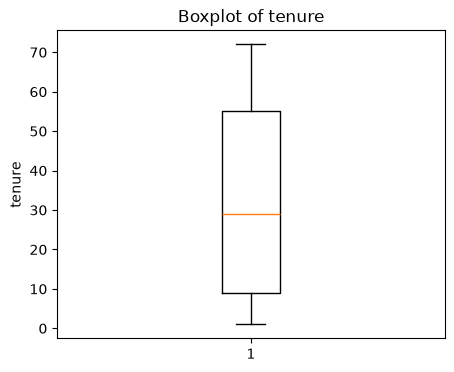

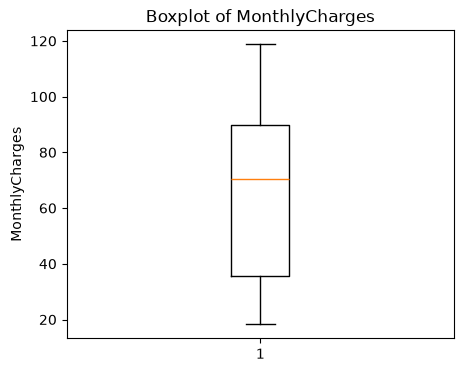

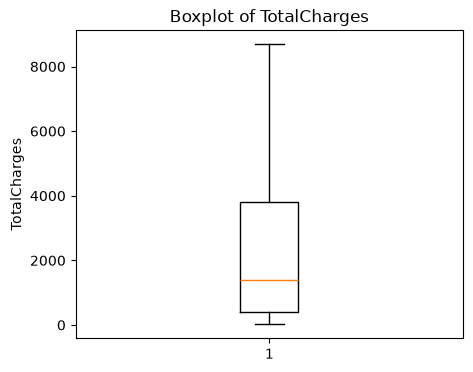

In [24]:
# Visualize the data using boxplots
import matplotlib.pyplot as plt

for column in outlier_columns:
    
    plt.figure(figsize=(5, 4))
    plt.boxplot(customer_churn[column].dropna())
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
    
    plt.show()

In [25]:
# Detect outliers using the IQR method
for column in outlier_columns:

    Q1 = customer_churn[column].quantile(0.25)
    Q3 = customer_churn[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = customer_churn[
        (customer_churn[column] < lower_bound) |
        (customer_churn[column] > upper_bound)
    ]

    print(f"\n{column}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {len(outliers)}")


tenure
Lower Bound: -60.0
Upper Bound: 124.0
Number of Outliers: 0

MonthlyCharges
Lower Bound: -45.824999999999996
Upper Bound: 171.27499999999998
Number of Outliers: 0

TotalCharges
Lower Bound: -4688.481250000001
Upper Bound: 8884.66875
Number of Outliers: 0


## **Why Customers Churn**

In [26]:
customer_churn['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

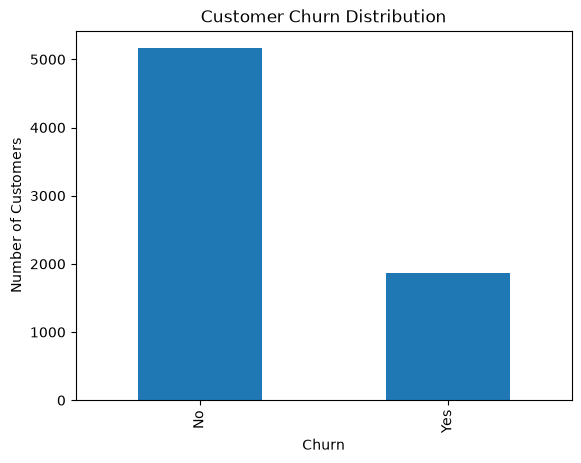

In [27]:
customer_churn['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

**There are more customers who did not churn**

In [28]:
numerical_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]
customer_churn[numerical_columns].describe()


,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


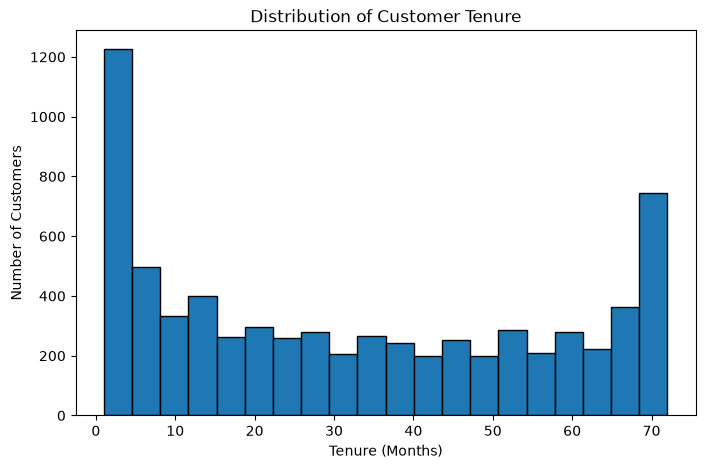

In [29]:
plt.figure(figsize=(8, 5))

plt.hist(
    customer_churn['tenure'],
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

plt.show()

**Most of the customer have a tenure of less than 5 months, with relative high number of customers having a tenure of 70 months**



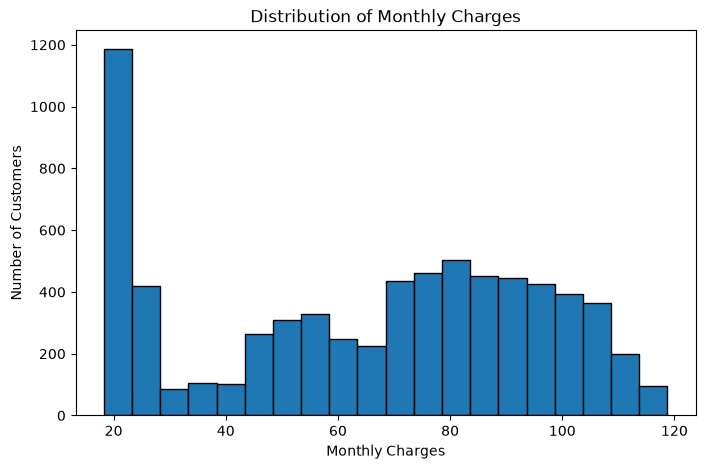

In [96]:
plt.figure(figsize=(8, 5))

plt.hist(
    customer_churn['MonthlyCharges'],
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')

plt.show()

**Most customer pefer monthly charge of 20sh, with relative number pefering charges betweeen 75 to 110 sh**

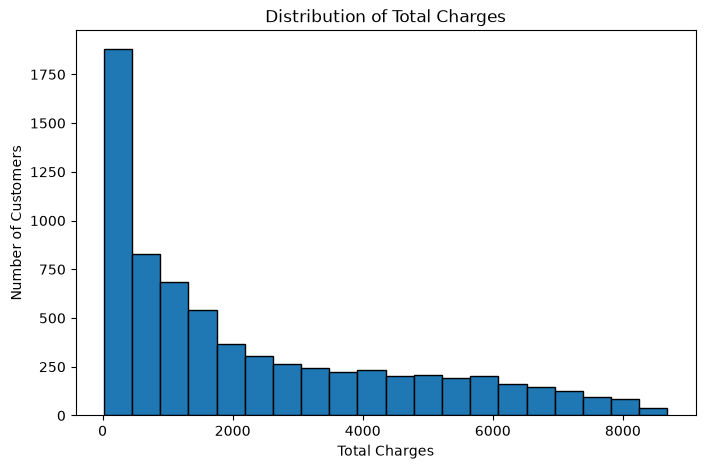

In [97]:
plt.figure(figsize=(8, 5))

plt.hist(
    customer_churn['TotalCharges'],
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')

plt.show()

### **Categorical EDA**

In [30]:
categorical_columns = customer_churn.select_dtypes(
    include=['object','str']
).columns

categorical_columns = categorical_columns.drop('customerID')
categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [31]:
customer_churn['gender'].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [32]:
customer_churn['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [33]:
customer_churn['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

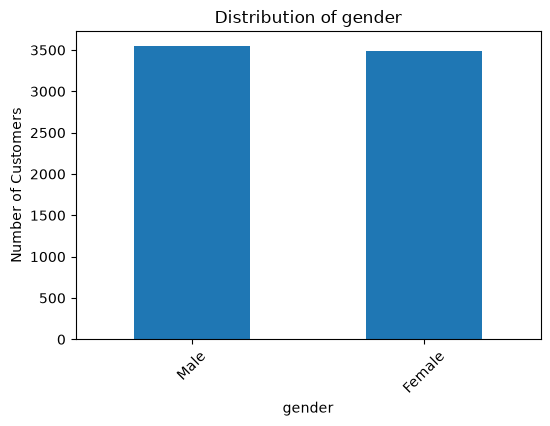

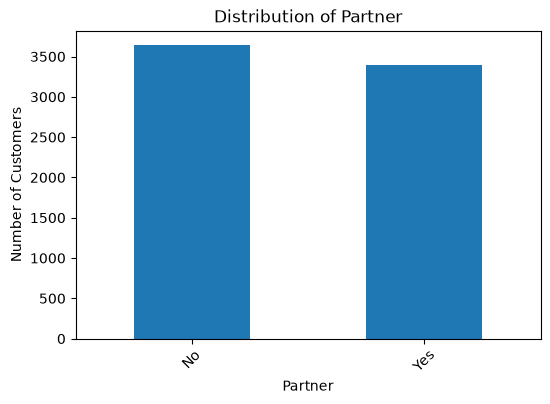

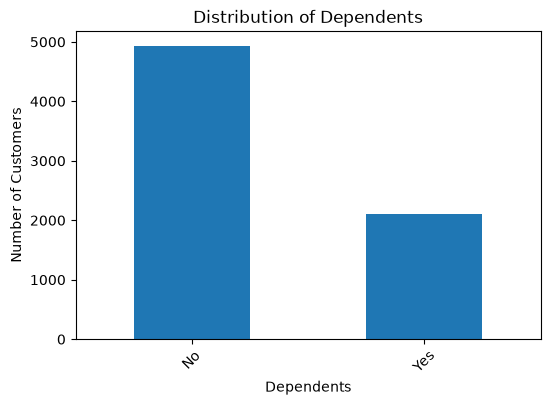

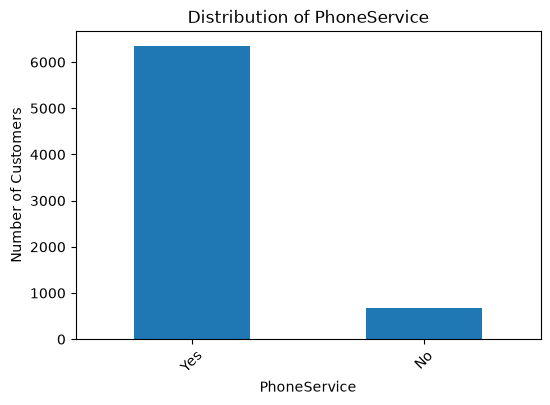

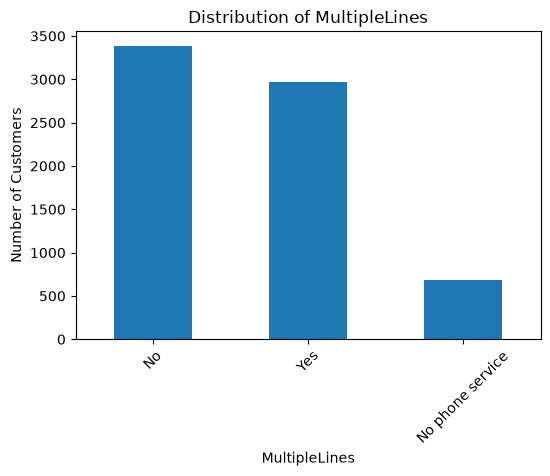

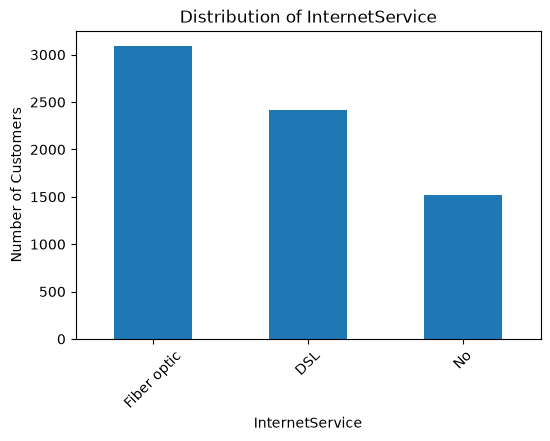

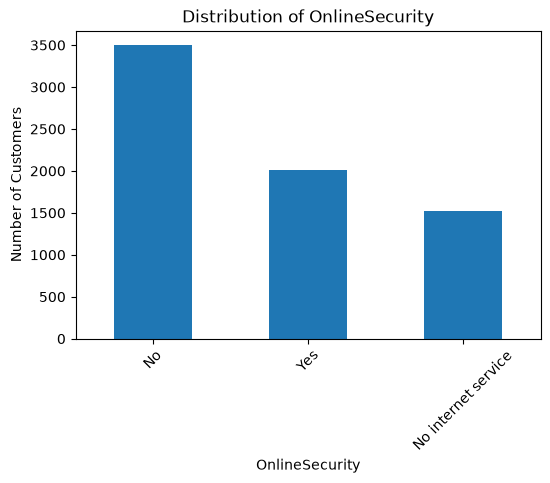

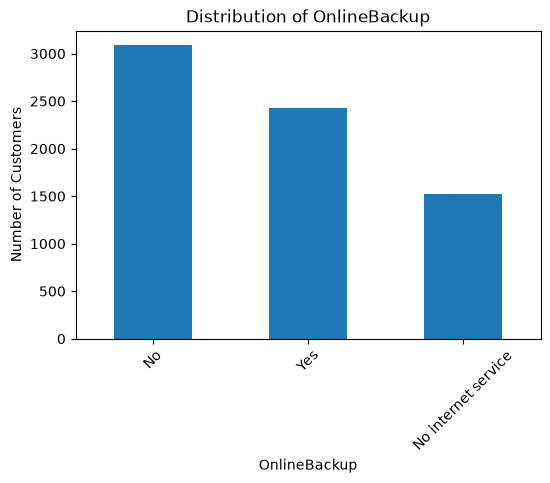

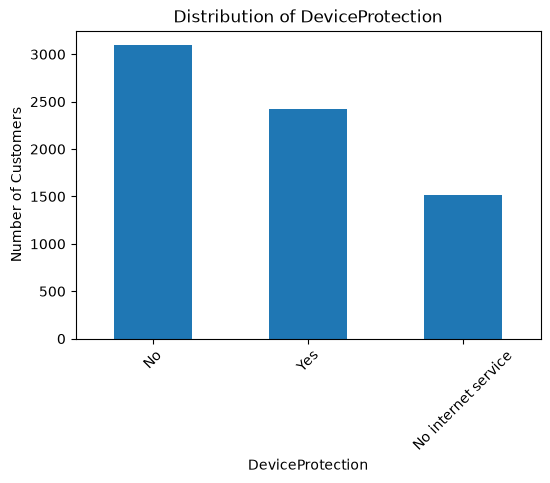

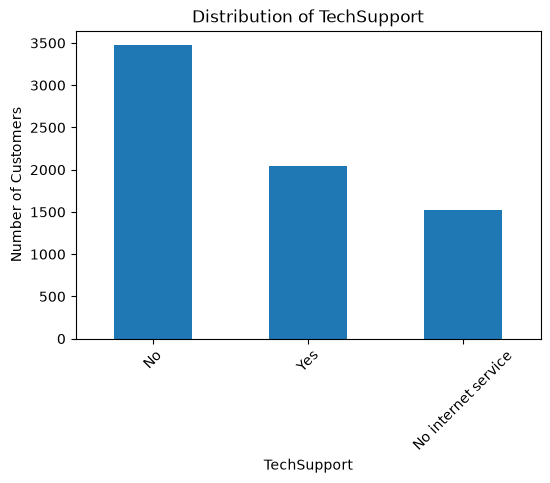

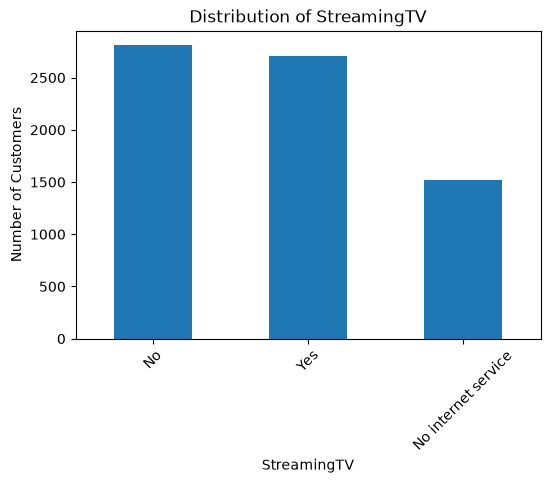

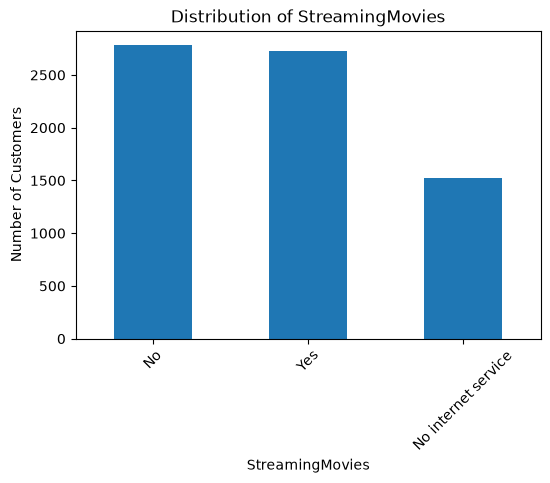

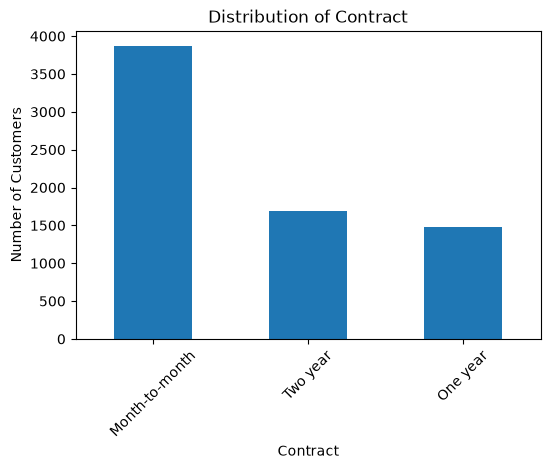

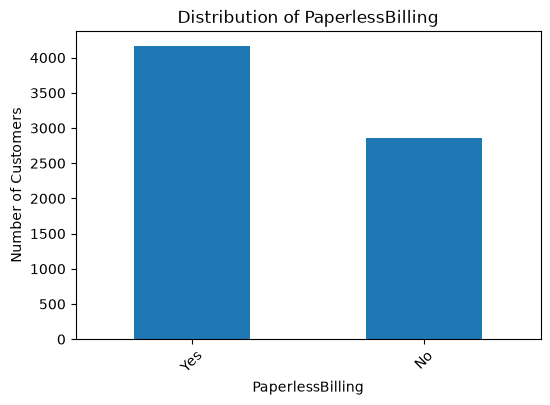

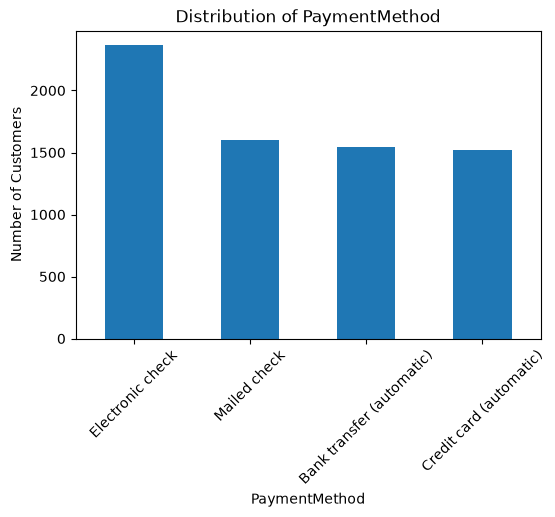

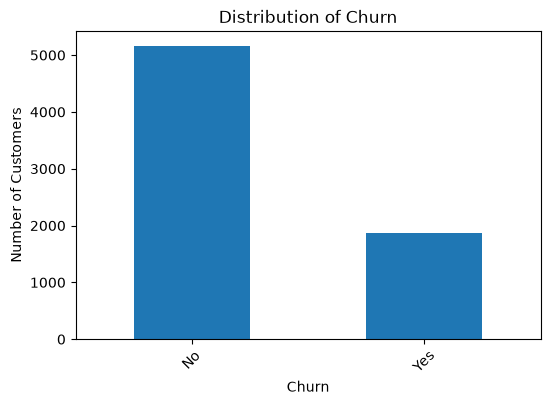

In [34]:
for column in categorical_columns:

    plt.figure(figsize=(6, 4))

    customer_churn[column].value_counts().plot(
        kind='bar'
    )

    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Number of Customers')

    plt.xticks(rotation=45)

    plt.show()

### **Numerical vs Churn**

**This helps answer:**

Do customers who churn have lower tenure?

Do customers who churn pay higher monthly charges?

Do churned customers have different total charges?

<Figure size 700x500 with 0 Axes>

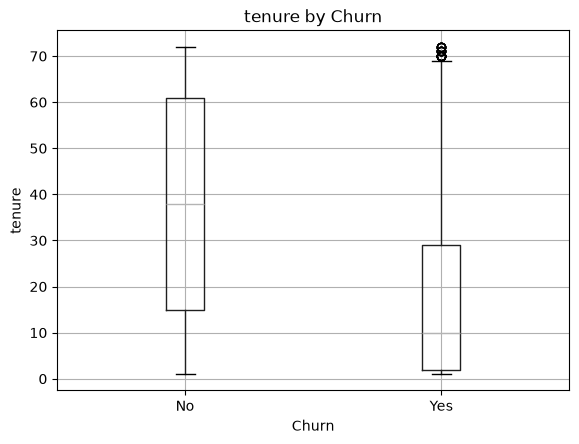

<Figure size 700x500 with 0 Axes>

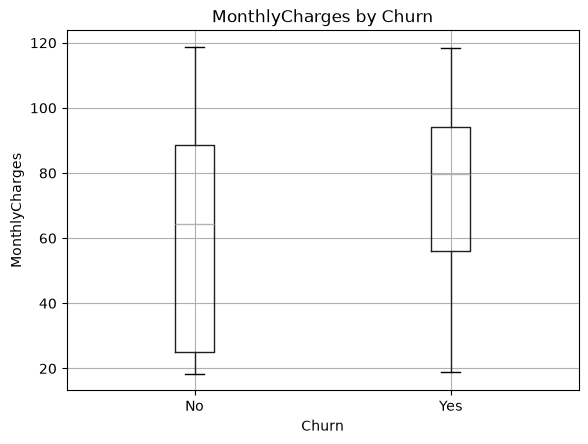

<Figure size 700x500 with 0 Axes>

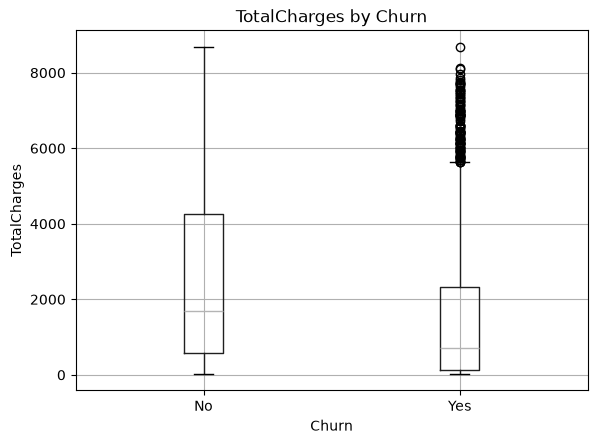

In [35]:
for column in numerical_columns:

    plt.figure(figsize=(7, 5))

    customer_churn.boxplot(
        column=column,
        by='Churn'
    )

    plt.title(f'{column} by Churn')
    plt.suptitle('')
    plt.xlabel('Churn')
    plt.ylabel(column)

    plt.show()

* Customers who churned generally had a significantly **shorter tenure** compared to customers who remained with the company. The **median tenure** of churned customers was substantially lower than that of retained customers, suggesting that the risk of churn is higher among relatively new customers. This highlights the importance of customer retention strategies and engagement during the early stages of the customer lifecycle.**

* There are a few customers with tenure close to 70–72 months who still churned

* Customers who churned generally had **higher monthly charges** but lower **total charges** compared to retained customers. This pattern is likely associated with shorter customer tenure, as customers who leave earlier have less time to accumulate total charges. The presence of some high-total-charge churned customers also highlights the risk of losing valuable long-term customers**

### **Categorical vs Churn**

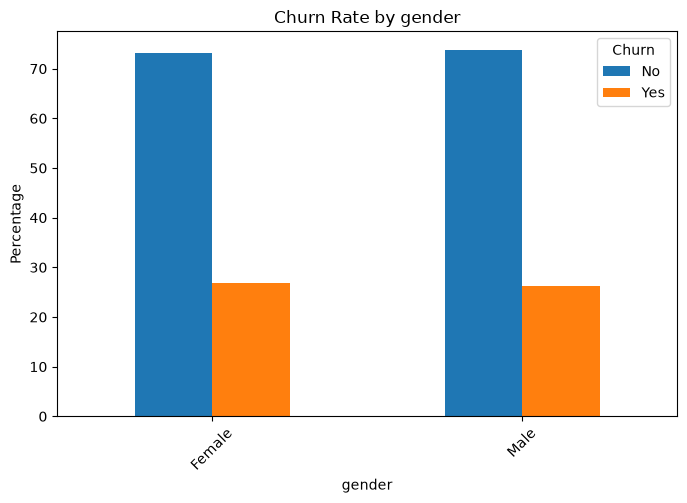

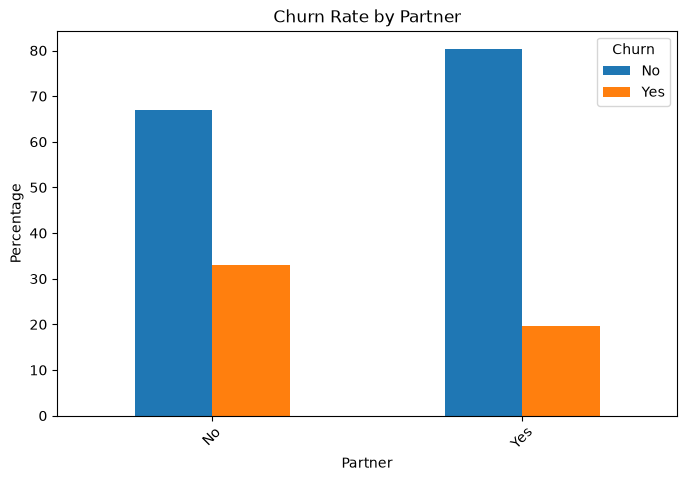

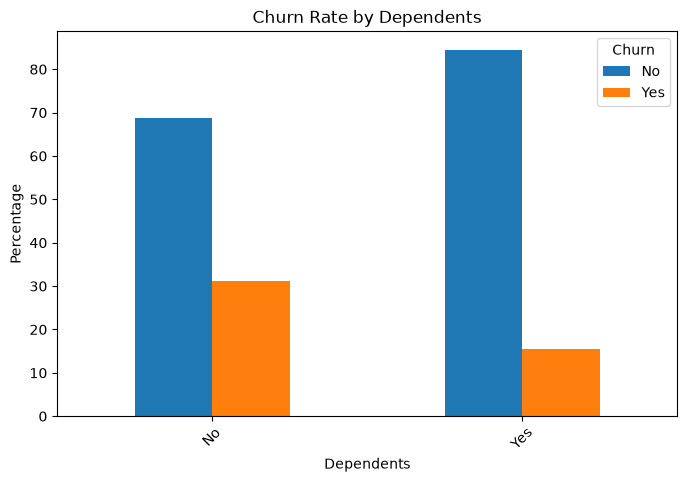

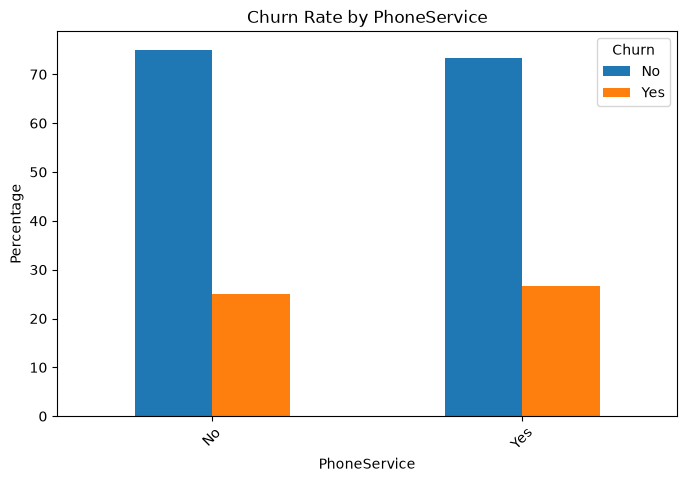

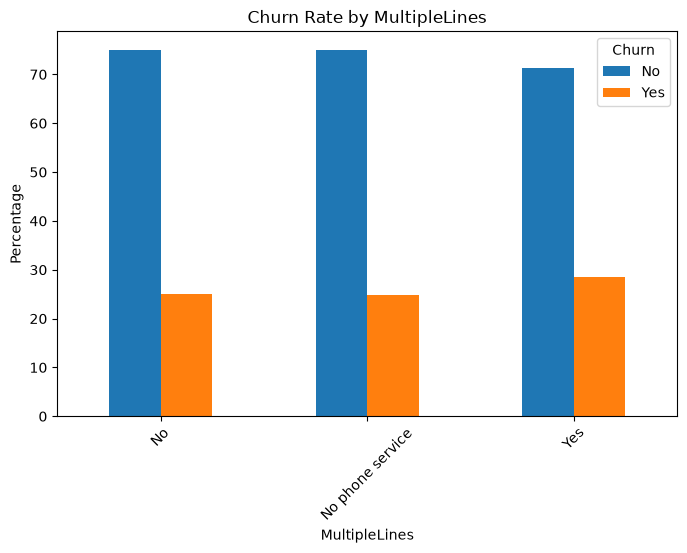

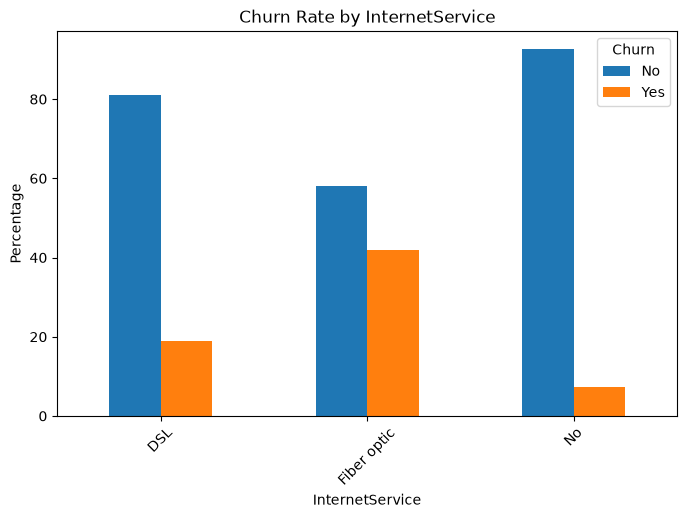

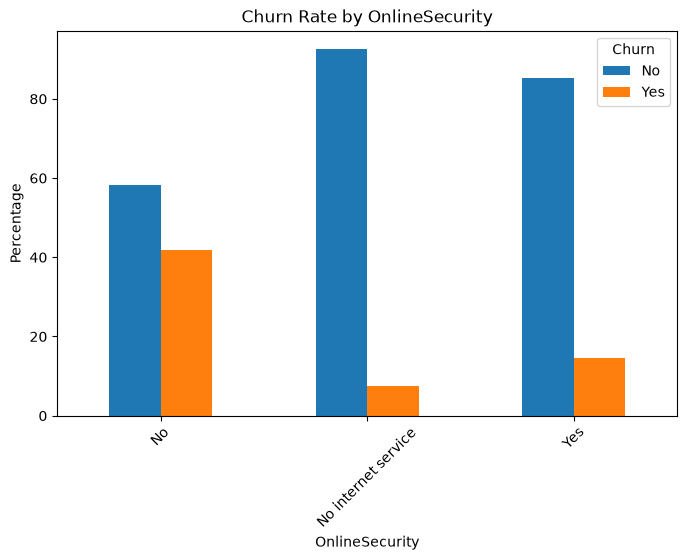

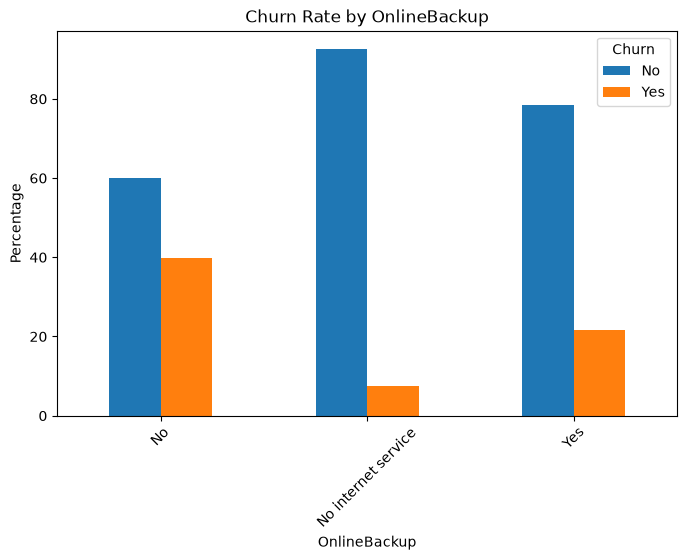

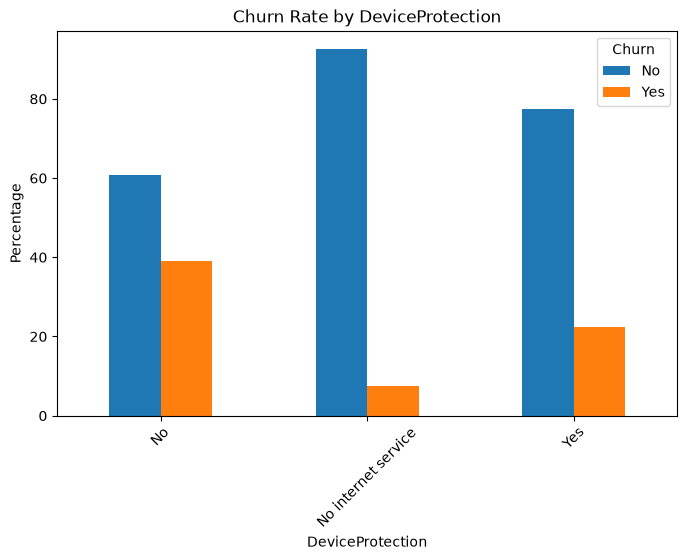

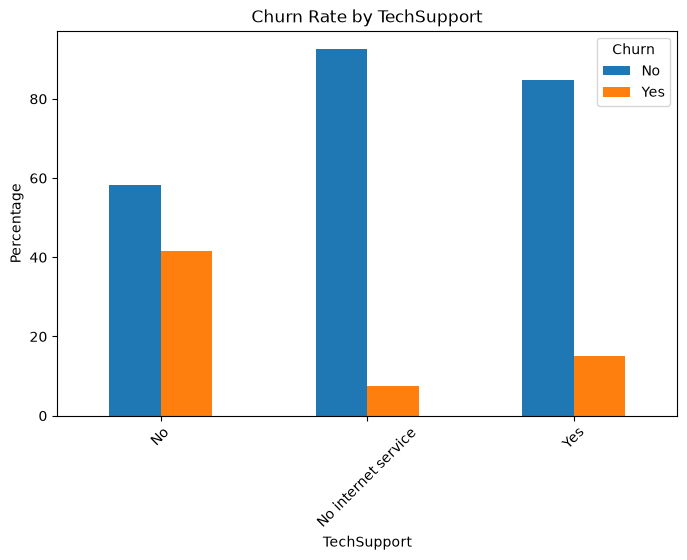

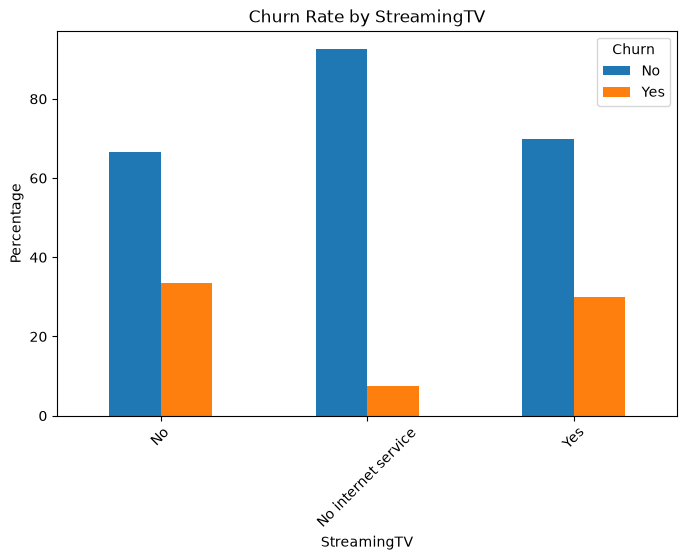

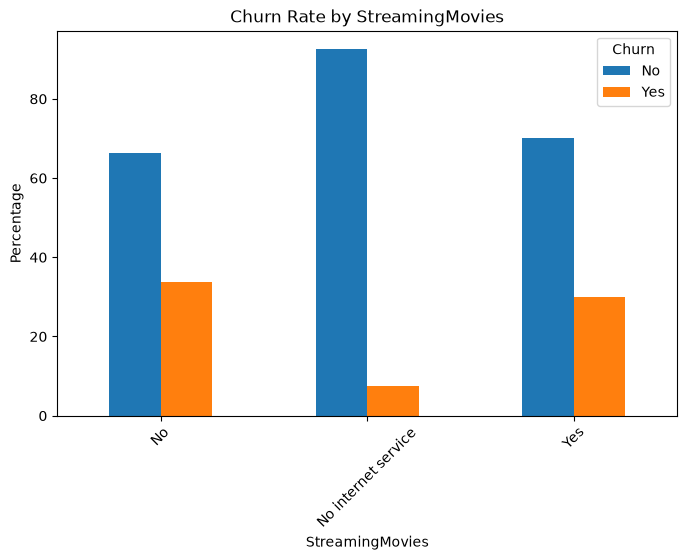

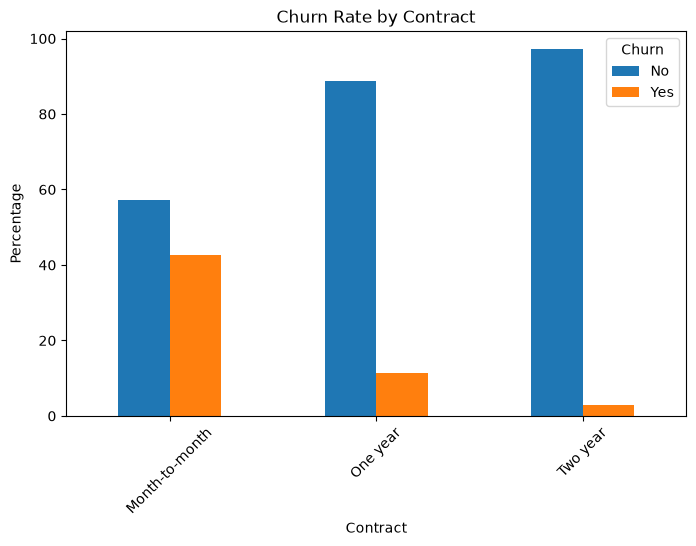

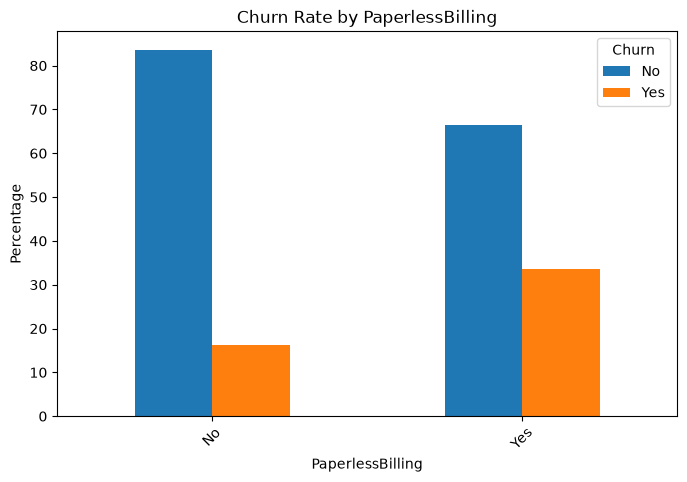

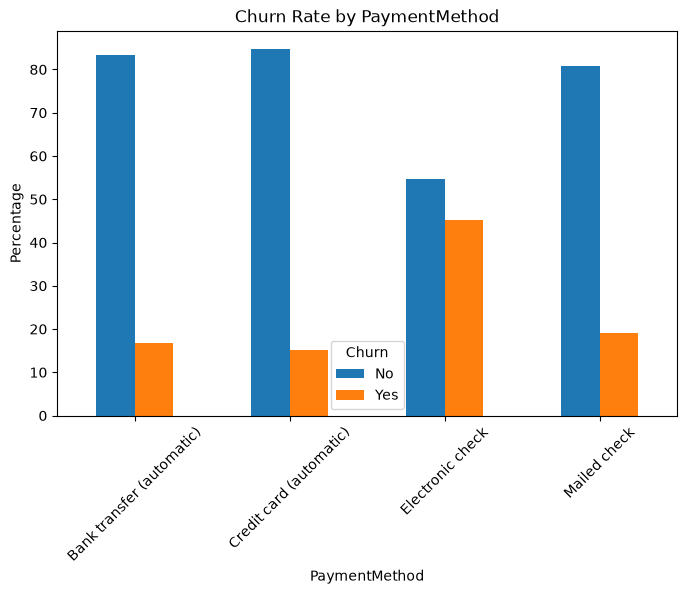

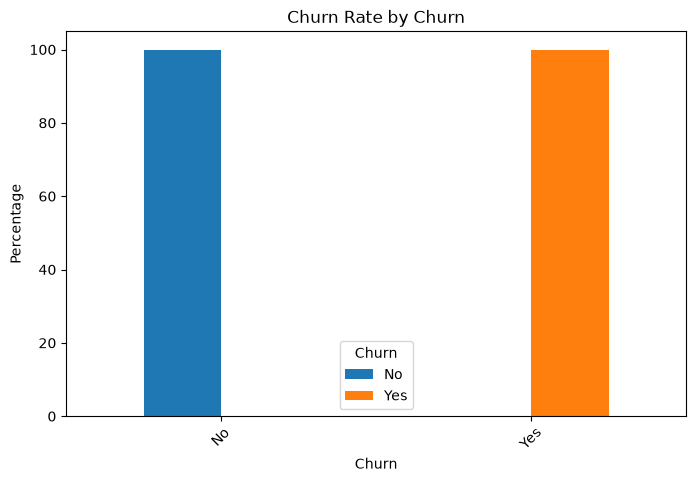

In [107]:
for column in categorical_columns:

    churn_rate = pd.crosstab(
        customer_churn[column],
        customer_churn['Churn'],
        normalize='index'
    ) * 100

    churn_rate.plot(
        kind='bar',
        figsize=(8, 5)
    )

    plt.title(f'Churn Rate by {column}')
    plt.xlabel(column)
    plt.ylabel('Percentage')

    plt.legend(title='Churn')

    plt.xticks(rotation=45)

    plt.show()

In [104]:
customer_churn['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [81]:
# seniorcitizen churn distribution
pd.crosstab(
    customer_churn['SeniorCitizen'],
    customer_churn['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


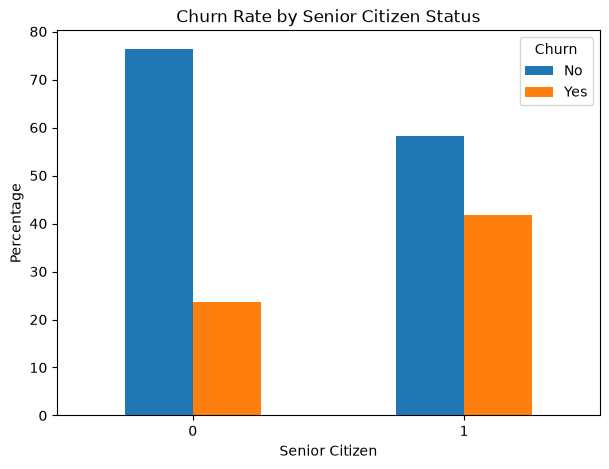

In [109]:
churn_rate = pd.crosstab(
    customer_churn['SeniorCitizen'],
    customer_churn['Churn'],
    normalize='index'
) * 100

churn_rate.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Churn Rate by Senior Citizen Status')
plt.xlabel('Senior Citizen')
plt.ylabel('Percentage')

plt.xticks([0, 1], rotation=0)

plt.show()

In [37]:
# 1. Create Tenure Segments
customer_churn['TenureSegment'] = pd.cut(
    customer_churn['tenure'],
    bins=[-1, 12, 36, 72],
    labels=[
        'New Customer',
        'Mid-Term Customer',
        'Long-Term Customer'
    ]
)


# 2. Create Customer Value Segments
customer_churn['CustomerValue'] = pd.qcut(
    customer_churn['TotalCharges'],
    q=3,
    labels=[
        'Low Value',
        'Medium Value',
        'High Value'
    ]
)


# 3. Define service columns
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]


# 4. Count the number of services for each customer
customer_churn['NumberOfServices'] = (
    customer_churn[service_columns] == 'Yes'
).sum(axis=1)


# 5. Create Service Usage Segments
customer_churn['ServiceSegment'] = pd.cut(
    customer_churn['NumberOfServices'],
    bins=[-1, 2, 5, 8],
    labels=[
        'Low Service Usage',
        'Moderate Service Usage',
        'High Service Usage'
    ]
)

In [38]:
customer_churn[
    [
        'tenure',
        'TenureSegment',
        'MonthlyCharges',
        'TotalCharges',
        'CustomerValue',
        'NumberOfServices',
        'ServiceSegment'
    ]
].head()

,tenure,TenureSegment,MonthlyCharges,TotalCharges,CustomerValue,NumberOfServices,ServiceSegment
0,1,New Customer,29.85,29.85,Low Value,1,Low Service Usage
1,34,Mid-Term Customer,56.95,1889.50,Medium Value,3,Moderate Service Usage
2,2,New Customer,53.85,108.15,Low Value,3,Moderate Service Usage
3,45,Long-Term Customer,42.30,1840.75,Medium Value,3,Moderate Service Usage
4,2,New Customer,70.70,151.65,Low Value,1,Low Service Usage


In [55]:
#Combined profile of segments
def customer_profile(row):

    if (
        row['CustomerValue'] == 'High Value'
        and row['TenureSegment'] == 'Long-Term Customer'
        and row['Churn'] == 'No'
    ):
        return 'High-Value Loyal'

    elif (
        row['CustomerValue'] == 'High Value'
        and row['Churn'] == 'Yes'
    ):
        return 'High-Value Churned'

    elif (
        row['TenureSegment'] == 'New Customer'
        and row['Churn'] == 'Yes'
    ):
        return 'New Customer Churned'

    elif row['NumberOfServices'] <= 2:
        return 'Low Engagement'

    else:
        return 'Standard Customer'

#applying the function
customer_churn['CustomerProfile'] = customer_churn.apply(
    customer_profile,
    axis=1
)
#Checking the Distribution of Customer Profiles
customer_churn['CustomerProfile'].value_counts()

CustomerProfile
Low Engagement          2274
High-Value Loyal        1833
Standard Customer       1501
New Customer Churned    1037
High-Value Churned       387
Name: count, dtype: int64

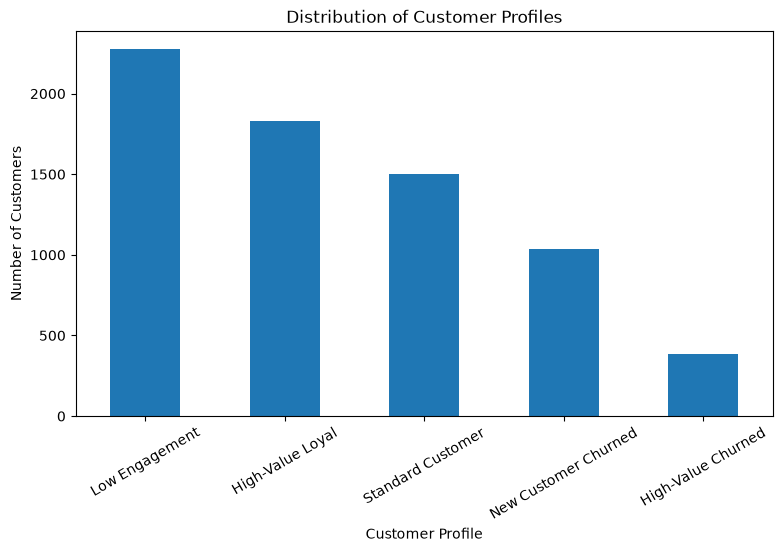

In [56]:
#Visualizing the Customer Profiles
customer_churn['CustomerProfile'].value_counts().plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Distribution of Customer Profiles')
plt.xlabel('Customer Profile')
plt.ylabel('Number of Customers')

plt.xticks(rotation=30)

plt.show()

In [ ]:
#Analysis of profile
# **This will help in understanding the characteristics of each segment.**
customer_segment_summary = customer_churn.groupby(
    'CustomerProfile',
    observed=True
).agg(
    Customers=('customerID', 'count'),
    Average_Tenure=('tenure', 'mean'),
    Average_Monthly_Charges=('MonthlyCharges', 'mean'),
    Average_Total_Charges=('TotalCharges', 'mean'),
    Average_Number_of_Services=('NumberOfServices', 'mean'),
    Churn_Rate=('Churn', lambda x: (x == 'Yes').mean() * 100)
).round(2)

customer_segment_summary

,Customers,Average_Tenure,Average_Monthly_Charges,Average_Total_Charges,Average_Number_of_Services,Churn_Rate
CustomerProfile,,,,,,
High-Value Churned,387,49.57,95.34,4743.79,5.09,100.00
High-Value Loyal,1833,60.38,87.77,5308.96,5.52,0.00
Low Engagement,2274,26.59,33.12,756.88,1.35,5.89
New Customer Churned,1037,4.01,66.49,288.53,2.34,100.00
Standard Customer,1501,22.32,75.69,1644.67,4.04,20.72


In [70]:
retention_strategy = pd.DataFrame({
    'Customer Segment': [
        'High-Value Loyal',
        'High-Value Churned',
        'New Customer Churned',
        'Low Engagement',
        'Standard Customer'
    ],
    
    'Business Objective': [
        'Maintain loyalty and protect revenue',
        'Understand and prevent high-value customer loss',
        'Improve early customer retention',
        'Increase customer engagement',
        'Maintain satisfaction and encourage growth'
    ],
    
    'Recommended Action': [
        'Loyalty rewards, priority support and personalised offers',
        'Exit analysis, proactive retention offers and improved support',
        'Better onboarding, early follow-up and introductory offers',
        'Relevant service bundles and personalised recommendations',
        'Customer satisfaction monitoring and targeted offers'
    ]
})

display(retention_strategy)

,Customer Segment,Business Objective,Recommended Action
0,High-Value Loyal,Maintain loyalty and protect revenue,"Loyalty rewards, priority support and personal..."
1,High-Value Churned,Understand and prevent high-value customer loss,"Exit analysis, proactive retention offers and ..."
2,New Customer Churned,Improve early customer retention,"Better onboarding, early follow-up and introdu..."
3,Low Engagement,Increase customer engagement,Relevant service bundles and personalised reco...
4,Standard Customer,Maintain satisfaction and encourage growth,Customer satisfaction monitoring and targeted ...


Customer segmentation revealed distinct groups with different business needs. Long-term, high-value customers should be prioritised for loyalty and retention programmes, while new customers who leave early require improved onboarding and early engagement. Customers with low service engagement may benefit from personalised service recommendations. The company should also investigate high-value churned customers to identify the causes of significant revenue loss.

In [72]:
revenue_by_segment = customer_churn.groupby(
    'CustomerProfile',
    observed=True
)['TotalCharges'].sum().sort_values(ascending=False)

display(revenue_by_segment)

CustomerProfile
High-Value Loyal        9731327.25
Standard Customer       2468645.50
High-Value Churned      1835847.90
Low Engagement          1721140.30
New Customer Churned     299207.75
Name: TotalCharges, dtype: float64

,Number_of_Customers,Total_Revenue,Average_Revenue_Per_Customer,Average_Monthly_Charges
CustomerProfile,,,,
High-Value Loyal,1833,9731327.25,5308.96,87.77
Standard Customer,1501,2468645.50,1644.67,75.69
High-Value Churned,387,1835847.90,4743.79,95.34
Low Engagement,2274,1721140.30,756.88,33.12
New Customer Churned,1037,299207.75,288.53,66.49


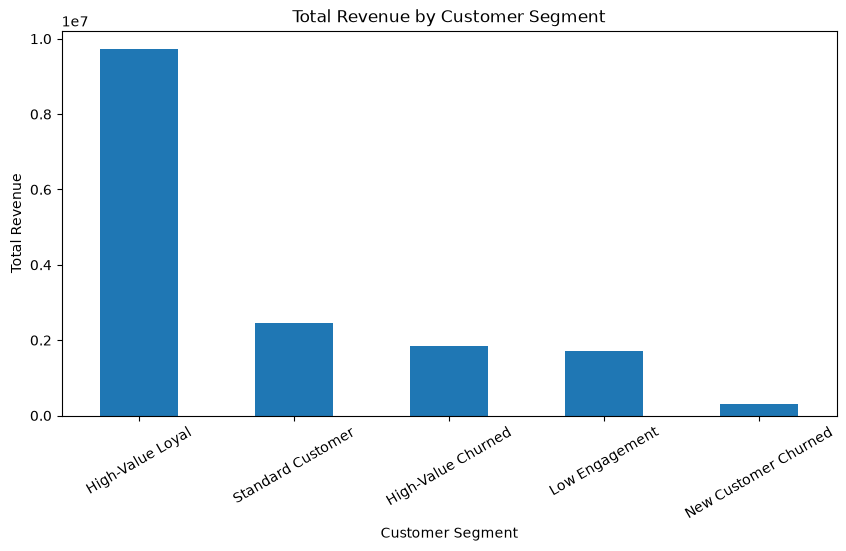

In [69]:
revenue_summary = customer_churn.groupby(
    'CustomerProfile',
    observed=True
).agg(
    Number_of_Customers=('customerID', 'count'),
    Total_Revenue=('TotalCharges', 'sum'),
    Average_Revenue_Per_Customer=('TotalCharges', 'mean'),
    Average_Monthly_Charges=('MonthlyCharges', 'mean')
).round(2)

revenue_summary = revenue_summary.sort_values(
    by='Total_Revenue',
    ascending=False
)

display(revenue_summary)
revenue_summary['Total_Revenue'].plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Total Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')

plt.xticks(rotation=30)

plt.show()

,Number_of_Customers,Total_Revenue,Average_Revenue_Per_Customer,Average_Monthly_Charges,Revenue_Contribution_%
CustomerProfile,,,,,
High-Value Loyal,1833,9731327.25,5308.96,87.77,60.61
Standard Customer,1501,2468645.50,1644.67,75.69,15.38
High-Value Churned,387,1835847.90,4743.79,95.34,11.43
Low Engagement,2274,1721140.30,756.88,33.12,10.72
New Customer Churned,1037,299207.75,288.53,66.49,1.86


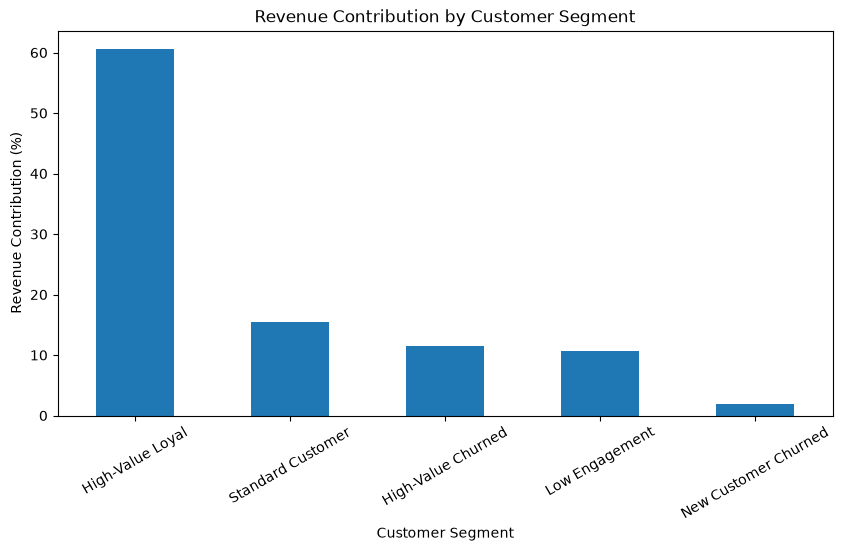

In [68]:
revenue_summary['Revenue_Contribution_%'] = (
    revenue_summary['Total_Revenue'] /
    revenue_summary['Total_Revenue'].sum() * 100
).round(2)

display(revenue_summary)

revenue_summary['Revenue_Contribution_%'].plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Revenue Contribution by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue Contribution (%)')

plt.xticks(rotation=30)

plt.show()